In [1]:
from simulator import Simulator  # type: ignore
from estimator import EKF, PF

import numpy as np
import time
from tqdm import tqdm
# from tqdm.contrib.itertools import product

np.random.seed(100)  # Set a fixed random seed for reproducibility

In [2]:
def evaluate(
    estimates_ekf: np.ndarray, estimates_pf: np.ndarray, simulator
):
    """
    Calculate the RMSE of all estimates.
    """
    ekf_implimented = np.all(np.logical_not(np.isnan(estimates_ekf)))
    pf_implimented = np.all(np.logical_not(np.isnan(estimates_pf)))

    ekf_rmse = None
    if ekf_implimented:
        rmse = np.sqrt(np.mean((estimates_ekf - simulator.states) ** 2, axis=1))
        ekf_rmse = rmse

    pf_rmse = None
    if pf_implimented:
        rmse = np.sqrt(
            np.mean((np.mean(estimates_pf, axis=2).T - simulator.states) ** 2, axis=1)
        )
        pf_rmse = rmse
    return ekf_rmse, pf_rmse

In [3]:
def simulate(noise_type: str, est_const):
    NUM_STATES = 5  # [x, y, psi, tau, l]
    simulator = Simulator(noise=noise_type)
    ekf = EKF(est_const)
    pf = PF(est_const, noise=noise_type)
    simulator.update_const(est_const)
    simulator.simulate()
    states = simulator.states
    inputs = simulator.inputs
    measurements = simulator.measurements

    # EKF containers
    estimates_ekf = np.zeros((NUM_STATES, est_const.N))
    variances_ekf = np.zeros((est_const.N, NUM_STATES, NUM_STATES))

    # PF containers
    estimates_pf = np.zeros((est_const.N, NUM_STATES, pf.num_particles))

    # Initialize the estimator
    estimates_ekf[:, 0], variances_ekf[0, :, :] = ekf.initialize()
    estimates_pf[0, :, :] = pf.initialize()

    # Run the EKF
    start = time.time()
    for k in range(1, est_const.N):
        # EKF
        estimates_ekf[:, k], variances_ekf[k, :, :] = ekf.estimate(
            estimates_ekf[:, k - 1],
            variances_ekf[k - 1, :, :],
            inputs[:, k - 1],
            measurements[:, k],
        )
    end = time.time()
    ekf_time = end - start

    # Run the PF
    start = time.time()
    for k in range(1, est_const.N):
        # PF
        estimates_pf[k, :, :] = pf.estimate(
            estimates_pf[k - 1, :, :],
            inputs[:, k - 1],
            measurements[:, k],
        )
    end = time.time()
    pf_time = end - start

    # Evaluate the estimates
    ekf_rmse, pf_rmse = evaluate(
        estimates_ekf, estimates_pf, simulator
    )

    return ekf_rmse, pf_rmse, ekf_time, pf_time

In [4]:
class EstimatorConstantVar:
    def __init__(self, sigma_beta=0.2, sigma_uc=0.2, sigma_GPS=8, start_radius_bound=5):
        self.l_lb = 1.0
        self.l_ub = 1.5
        self.sigma_beta = sigma_beta
        self.sigma_uc = sigma_uc
        self.sigma_GPS = sigma_GPS
        self.sigma_tau = 1
        self.sigma_psi = 30 / 180 * np.pi
        self.start_radius_bound = start_radius_bound
        self.start_heading_bound = np.pi / 4
        self.start_velocity_bound = 10
        self.N = 2000
        self.Ts = 0.01

In [5]:
from concurrent.futures import ProcessPoolExecutor
from itertools import product
from tqdm import tqdm
import numpy as np

def run_simulation(args):
    sigma_beta, sigma_uc, sigma_GPS, start_radius_bound = args
    est_const = EstimatorConstantVar(
        sigma_beta=sigma_beta,
        sigma_uc=sigma_uc,
        sigma_GPS=sigma_GPS,
        start_radius_bound=start_radius_bound,
    )
    ekf_rmse, pf_rmse, ekf_time, pf_time = simulate("Gaussian", est_const)
    return (ekf_rmse, ekf_time), (pf_rmse, pf_time)

sigma_betas = np.arange(0.1, 1, 0.2)
sigma_ucs = np.arange(0.1, 1, 0.2)
sigma_GPSs = np.arange(4, 25, 3)
start_radius_bounds = np.arange(2, 15, 3)
all_params = list(product(sigma_betas, sigma_ucs, sigma_GPSs, start_radius_bounds))

ekf_res_list = []
pf_res_list = []

with ProcessPoolExecutor() as executor:
    results = list(tqdm(executor.map(run_simulation, all_params), total=len(all_params)))

for ekf_result, pf_result in results:
    ekf_res_list.append(ekf_result)
    pf_res_list.append(pf_result)

100%|██████████| 875/875 [38:07<00:00,  2.61s/it]


In [10]:
def params_to_estimatorConstVar(params):
    sigma_beta, sigma_uc, sigma_GPS, start_radius_bound = params
    return EstimatorConstantVar(
        sigma_beta=sigma_beta,
        sigma_uc=sigma_uc,
        sigma_GPS=sigma_GPS,
        start_radius_bound=start_radius_bound,
    )

In [49]:
import pickle
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [17]:
with open("results.pkl", "wb") as f:
    pickle.dump({
        "ekf_res_list": ekf_res_list,
        "pf_res_list": pf_res_list,
        "params": all_params,
    }, f)

In [34]:
params = np.array(all_params)

In [30]:
ekf_res, pf_res = list(zip(*ekf_res_list)), list(zip(*pf_res_list))

In [31]:
ekf_rmse = np.array(ekf_res[0])
ekf_time = np.array(ekf_res[1])
pf_rmse = np.array(pf_res[0])
pf_time = np.array(pf_res[1])

In [36]:
ekf_rmse.shape

(875, 5)

In [37]:
np.argmax(ekf_rmse, axis=0)

array([593, 205, 700, 510, 489])

In [45]:
ekf_df = pd.DataFrame({
    "x_rmse": ekf_rmse[:, 0],
    "y_rmse": ekf_rmse[:, 1],
    "psi_rmse": ekf_rmse[:, 2],
    "tau_rmse": ekf_rmse[:, 3],
    "l_rmse": ekf_rmse[:, 4],
    "time": ekf_time,
    "sigma_beta": params[:, 0],
    "sigma_uc": params[:, 1],
    "sigma_GPS": params[:, 2],
    "start_radius_bound": params[:, 3],
})
ekf_df.head()

,x_rmse,y_rmse,psi_rmse,tau_rmse,l_rmse,time,sigma_beta,sigma_uc,sigma_GPS,start_radius_bound
0,0.721496,0.782831,0.084937,0.139075,0.149726,1.605480,0.1,0.1,4.0,2.0
1,0.724351,0.735857,0.085624,0.140596,0.152422,1.447495,0.1,0.1,4.0,5.0
2,0.726376,0.720481,0.085889,0.141014,0.153588,1.358880,0.1,0.1,4.0,8.0
3,0.727683,0.712602,0.086037,0.141209,0.154272,1.431013,0.1,0.1,4.0,11.0
4,0.728595,0.707763,0.086133,0.141323,0.154730,1.340432,0.1,0.1,4.0,14.0


In [46]:
pf_df = pd.DataFrame({
    "x_rmse": pf_rmse[:, 0],
    "y_rmse": pf_rmse[:, 1],
    "psi_rmse": pf_rmse[:, 2],
    "tau_rmse": pf_rmse[:, 3],
    "l_rmse": pf_rmse[:, 4],
    "time": pf_time,
    "sigma_beta": params[:, 0],
    "sigma_uc": params[:, 1],
    "sigma_GPS": params[:, 2],
    "start_radius_bound": params[:, 3],
})
pf_df.head()

,x_rmse,y_rmse,psi_rmse,tau_rmse,l_rmse,time,sigma_beta,sigma_uc,sigma_GPS,start_radius_bound
0,2.646757,2.221097,0.284077,0.238526,0.217743,9.427543,0.1,0.1,4.0,2.0
1,1.334575,1.140594,0.154996,0.262442,0.467127,9.314865,0.1,0.1,4.0,5.0
2,1.903491,1.765930,0.240285,0.273247,0.283018,9.616465,0.1,0.1,4.0,8.0
3,2.018541,1.844374,0.249702,0.250772,0.291017,10.041191,0.1,0.1,4.0,11.0
4,1.351891,1.388098,0.164936,0.222032,0.480793,9.753425,0.1,0.1,4.0,14.0


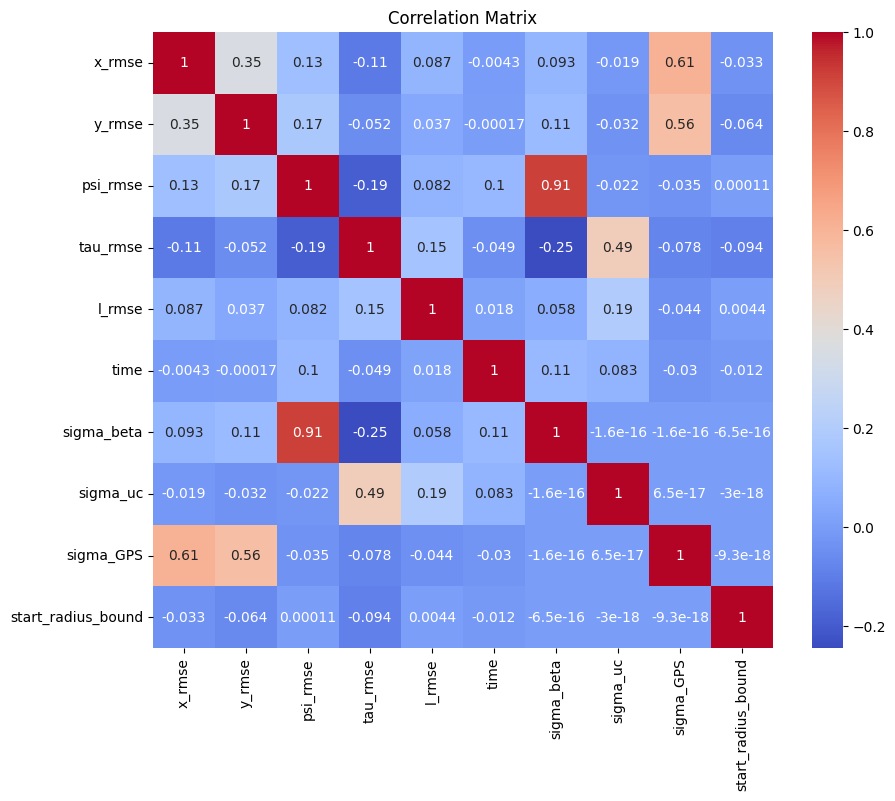

In [52]:
corr = ekf_df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

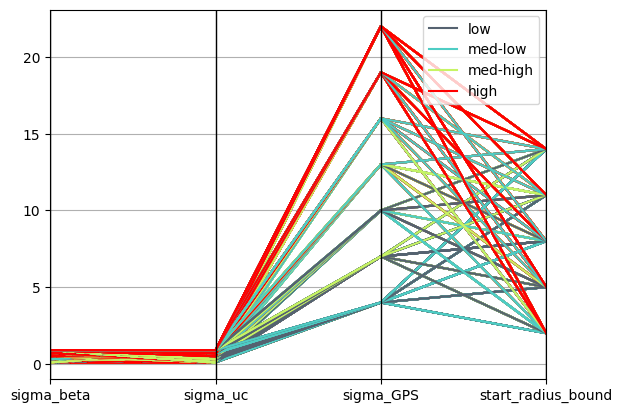

In [61]:
ekf_df["total_rmse"] = ekf_df[["x_rmse", "y_rmse", "psi_rmse", "tau_rmse", "l_rmse"]].sum(axis=1)
ekf_df["rmse_bin"] = pd.qcut(ekf_df["total_rmse"], q=4, labels=["low", "med-low", "med-high", "high"])
pd.plotting.parallel_coordinates(ekf_df[["sigma_beta", "sigma_uc", "sigma_GPS", "start_radius_bound", "rmse_bin"]], 'rmse_bin', color=('#556270', '#4ECDC4', '#C7F464', '#ff0000'))
plt.show()

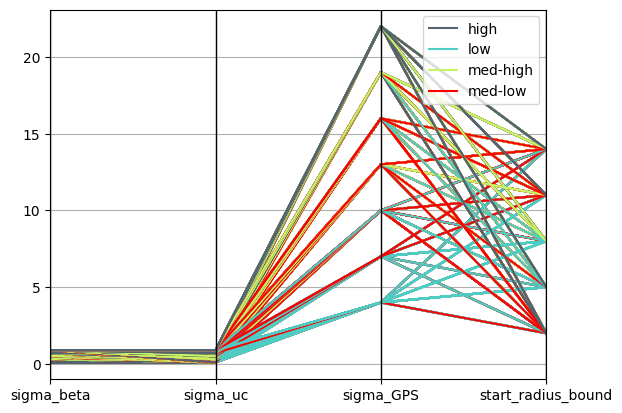

In [60]:
pf_df["total_rmse"] = pf_df[["x_rmse", "y_rmse", "psi_rmse", "tau_rmse", "l_rmse"]].sum(axis=1)
pf_df["rmse_bin"] = pd.qcut(pf_df["total_rmse"], q=4, labels=["low", "med-low", "med-high", "high"])
pd.plotting.parallel_coordinates(pf_df[["sigma_beta", "sigma_uc", "sigma_GPS", "start_radius_bound", "rmse_bin"]], 'rmse_bin', color=('#556270', '#4ECDC4', '#C7F464', '#ff0000'))
plt.show()

In [57]:
ekf_df[ekf_df["total_rmse"] == ekf_df["total_rmse"].max()]

,x_rmse,y_rmse,psi_rmse,tau_rmse,l_rmse,time,sigma_beta,sigma_uc,sigma_GPS,start_radius_bound,total_rmse,rmse_bin
205,1.945808,3.217018,0.137636,0.082345,0.367024,4.20263,0.3,0.1,22.0,2.0,5.74983,high


In [62]:
pf_df[pf_df["total_rmse"] == pf_df["total_rmse"].max()]

,x_rmse,y_rmse,psi_rmse,tau_rmse,l_rmse,time,sigma_beta,sigma_uc,sigma_GPS,start_radius_bound,total_rmse,rmse_bin
29,22.624667,36.952244,0.578537,0.232765,0.093236,13.97554,0.1,0.1,19.0,14.0,60.481449,high


In [64]:
simulate("Gaussian", EstimatorConstantVar(0.1, 0.1, 19, 14))

(array([1.67560916, 1.61535107, 0.10140537, 0.13060281, 0.15600615]),
 array([5.87029437, 5.20334303, 0.28061041, 0.24629981, 0.36600197]),
 0.1691586971282959,
 4.750157356262207)